In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

%matplotlib inline

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv')

In [3]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [4]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


#### Preparing the dataset

Preparation:
- Fill missing values with zeros.
- Do train/validation/test split with 60%/20%/20% distribution.
- Use the train_test_split function and set the random_state parameter to 1.
- Use DictVectorizer(sparse=True) to turn the dataframes into matrices.


In [5]:
df = df.fillna(0)
df.isnull().sum()

engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
fuel_efficiency_mpg    0
dtype: int64

In [7]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_train), len(df_val), len(df_test)

(5822, 1941, 1941)

In [8]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [9]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [10]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

#### Question 1

Let's train a decision tree regressor to predict the fuel_efficiency_mpg variable.
- Train a model with max_depth=1.

Which feature is used for splitting the data?

In [11]:
from sklearn.tree import DecisionTreeRegressor

In [12]:
def train(df_train, y_train, max_depth=1):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    dt = DecisionTreeRegressor(max_depth=max_depth)
    dt.fit(X_train, y_train)

    return dv, dt

In [13]:
def predict(df, dv, model):
    dicts = df.to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict(X)

    return y_pred

In [14]:
dv, model = train(df_train, y_train)

In [15]:
y_pred = predict(df_val, dv, model)

In [16]:
len(y_pred)

1941

In [17]:
from sklearn.tree import export_text

In [18]:
print(export_text(model, feature_names=dv.get_feature_names_out()))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



#### Question 2

Train a random forest regressor with these parameters:
- n_estimators=10
- random_state=1
- n_jobs=-1 (optional - to make training faster)

What's the RMSE of this model on the validation data?

In [19]:
from sklearn.ensemble import RandomForestRegressor

In [20]:
def rf_train(df_train, y_train, n_estimators=10):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    rf = RandomForestRegressor(n_estimators=n_estimators, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)

    return dv, rf

In [21]:
def rf_predict(df, dv, model):
    dicts = df.to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict(X)

    return y_pred

In [22]:
dv, model = rf_train(df_train, y_train)

In [23]:
y_pred = rf_predict(df_val, dv, model)

In [24]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [25]:
rmse_value = rmse(y_val, y_pred)
print(f"RMSE is: {round(rmse_value,2)}")

RMSE is: 0.46


#### Question 3

Now let's experiment with the n_estimators parameter
- Try different values of this parameter from 10 to 200 with step 10.
- Set random_state to 1.
- Evaluate the model on the validation dataset.

After which value of n_estimators does RMSE stop improving? Consider 3 decimal places for calculating the answer.

In [26]:
estimators = np.arange(10, 210, 10)

In [27]:
rmse_scores = []
for n in estimators:
    dv, model = rf_train(df_train, y_train, n_estimators=n)
    y_pred = rf_predict(df_val, dv, model)
    rmse_scores.append((n, round(rmse(y_val, y_pred),3)))

rmse_scores

[(10, 0.46),
 (20, 0.454),
 (30, 0.451),
 (40, 0.448),
 (50, 0.446),
 (60, 0.445),
 (70, 0.445),
 (80, 0.445),
 (90, 0.445),
 (100, 0.444),
 (110, 0.443),
 (120, 0.444),
 (130, 0.443),
 (140, 0.443),
 (150, 0.443),
 (160, 0.443),
 (170, 0.443),
 (180, 0.442),
 (190, 0.443),
 (200, 0.443)]

#### Question 4

Let's select the best max_depth:
- Try different values of max_depth: [10, 15, 20, 25]
- For each of these values,
    - try different values of n_estimators from 10 till 200 (with step 10)
    - calculate the mean RMSE
- Fix the random seed: random_state=1

What's the best max_depth, using the mean RMSE?

In [28]:
depth = [10, 15, 20, 25]

In [29]:
def d_n_rf_train(df_train, y_train, n_estimators=10, max_depth=10):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    rf = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)

    return dv, rf

In [30]:
scores = []

for d in depth:
    for n in estimators:
        dv, model = d_n_rf_train(df_train, y_train, n_estimators=n, max_depth=d)
        y_pred = rf_predict(df_val, dv, model)
        scores.append((d, n, round(rmse(y_val, y_pred),3)))

In [31]:
columns = ['max_depth', 'n_estimators', 'rmse']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,max_depth,n_estimators,rmse
0,10,10,0.452
1,10,20,0.449
2,10,30,0.446
3,10,40,0.444
4,10,50,0.443


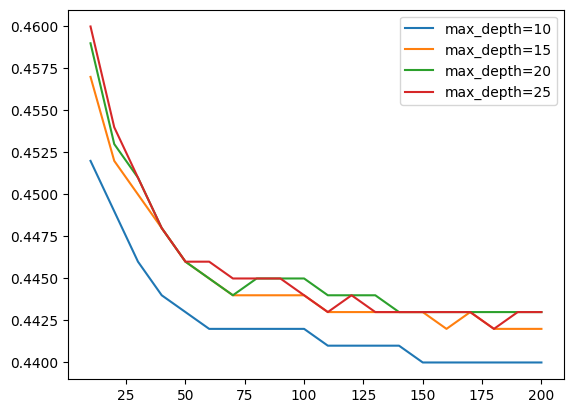

In [32]:
for d in depth:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.rmse, label='max_depth=%d' %d)
plt.legend()

#### Question 5

We can extract feature importance information from tree-based models. At each step of the decision tree learning algorithm, it finds the best split. When doing it, we can calculate "gain" - the reduction in impurity before and after the split. This gain is quite useful in understanding what are the important features for tree-based models. In Scikit-Learn, tree-based models contain this information in the feature_importances_ field.

For this homework question, we'll find the most important feature:
- Train the model with these parameters:
    - n_estimators=10,
    - max_depth=20,
    - random_state=1,
    - n_jobs=-1 (optional)
- Get the feature importance information from this model

What's the most important feature (among these 4)?

In [33]:
dv, model = d_n_rf_train(df_train, y_train, n_estimators=10, max_depth=20)
model.feature_importances_

array([1.14707165e-02, 3.81809750e-04, 3.11842085e-04, 3.26932342e-03,
       3.43693411e-04, 3.36671988e-04, 1.60402148e-02, 3.18229841e-03,
       2.35867094e-03, 1.59113306e-03, 4.76103046e-04, 5.20358083e-04,
       5.55151959e-04, 9.59162013e-01])

In [34]:
dv.get_feature_names_out()

array(['acceleration', 'drivetrain=All-wheel drive',
       'drivetrain=Front-wheel drive', 'engine_displacement',
       'fuel_type=Diesel', 'fuel_type=Gasoline', 'horsepower',
       'model_year', 'num_cylinders', 'num_doors', 'origin=Asia',
       'origin=Europe', 'origin=USA', 'vehicle_weight'], dtype=object)

In [35]:
ft_importances = []

for f in range(len(model.feature_importances_)):
    ft_importances.append((dv.get_feature_names_out()[f], model.feature_importances_[f]))
np.sort(ft_importances, axis=0)[::-1]

array([['vehicle_weight', '0.9591620125325987'],
       ['origin=USA', '0.016040214819390435'],
       ['origin=Europe', '0.011470716492980806'],
       ['origin=Asia', '0.003269323417164296'],
       ['num_doors', '0.003182298414589243'],
       ['num_cylinders', '0.002358670936092339'],
       ['model_year', '0.0015911330645071602'],
       ['horsepower', '0.0005551519590829983'],
       ['fuel_type=Gasoline', '0.0005203580827405701'],
       ['fuel_type=Diesel', '0.0004761030460744537'],
       ['engine_displacement', '0.0003818097503064216'],
       ['drivetrain=Front-wheel drive', '0.0003436934113118486'],
       ['drivetrain=All-wheel drive', '0.0003366719883675566'],
       ['acceleration', '0.0003118420847931972']], dtype='<U32')

#### Question 6

Now let's train an XGBoost model! For this question, we'll tune the eta parameter:
- Install XGBoost
- Create DMatrix for train and validation
- Create a watchlist
- Train a model with these parameters for 100 rounds:
    - xgb_params = {
        - 'eta': 0.3, 
        - 'max_depth': 6,
        - 'min_child_weight': 1,
        - 'objective': 'reg:squarederror',
        - 'nthread': 8,
        - 'seed': 1,
        - 'verbosity': 1,
      }
- Now change eta from 0.3 to 0.1.

Which eta leads to the best RMSE score on the validation dataset?

In [36]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: /usr/local/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [37]:
import xgboost as xgb

In [38]:
train_dicts = df_train.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

In [39]:
features = dv.get_feature_names_out().tolist()
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [40]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'reg:squarederror',
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
model = xgb.train(xgb_params, dtrain, num_boost_round=100)

In [41]:
y_pred = model.predict(dval)

In [42]:
rmse(y_val, y_pred)

0.45017755678087246

In [43]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'reg:squarederror',
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
model = xgb.train(xgb_params, dtrain, num_boost_round=100)
y_pred = model.predict(dval)
rmse(y_val, y_pred)

0.42622800553359225